# The Variance Ratio Test: Does Momentum Actually Exist in Your Asset?

**Cordell Tanny, CFA, FRM, FDP**  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/quant-finance-snippets](https://github.com/ctanny/quant-finance-snippets)

---

Before you build a momentum strategy, there is one question worth answering first: does momentum actually exist in the asset you are trading, at the frequency you intend to trade it?

Most practitioners skip this step. They build the strategy, run the backtest, and then spend weeks tuning parameters trying to fix something that was broken from the start. The variance ratio test gives you a statistically rigorous answer before you write a single line of strategy code.

The test was introduced by Lo and MacKinlay in 1988 and remains one of the most useful diagnostics in quantitative finance. It tests the random walk hypothesis directly, and the result tells you whether momentum or mean reversion has a statistical foundation in your data.

In this notebook we test two assets that could not be more different from each other: SPY as a broad market index, and NVDA as one of the most celebrated momentum stocks of the past decade. The contrast between them reveals something important about where momentum actually lives.

What this notebook covers:
1. What the variance ratio test is asking and why it matters
2. Full-sample test on SPY and NVDA across multiple horizons
3. Rolling variance ratio for each asset
4. A direct comparison and what it means for strategy design

> Note on implementation: we use the `arch` library's `VarianceRatio` class throughout. It implements the Lo-MacKinlay 1988 heteroskedasticity-robust estimator with proper de-biasing and has been peer reviewed and widely tested. All returns are weekly log returns resampled from daily prices.


## 1. Imports and Setup

In [ ]:
# If running on Colab:
!pip install arch -q

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch.unitroot import VarianceRatio
import warnings
warnings.filterwarnings('ignore')

# ── Parameters ─────────────────────────────────────────────────────────────
TICKERS        = ['SPY', 'NVDA']
START_DATE     = '2015-01-01'
ALPHA          = 0.05

# Holding period horizons to test (in weeks)
HORIZONS       = [2, 4, 8, 16]

# Rolling window (in weeks)
ROLLING_WINDOW = 104  # 2 years

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.3 MB/s eta 0:00:00


In [ ]:
# Download and resample to weekly log returns
returns = {}

for ticker in TICKERS:
    raw    = yf.download(ticker, start=START_DATE,
                         auto_adjust=True, progress=False)['Close'].squeeze()
    weekly = raw.resample('W').last().dropna()
    ret    = np.log(weekly / weekly.shift(1)).dropna()
    returns[ticker] = ret
    print(f"{ticker}: {len(ret)} weekly observations | "
          f"{ret.index[0].date()} to {ret.index[-1].date()} | "
          f"Ann. mean: {ret.mean()*52:.1%} | Ann. vol: {ret.std()*np.sqrt(52):.1%}")

SPY: 596 weekly observations | 2015-01-11 to 2026-06-07 | Ann. mean: 12.8% | Ann. vol: 16.8%
NVDA: 596 weekly observations | 2015-01-11 to 2026-06-07 | Ann. mean: 52.8% | Ann. vol: 44.3%


## 2. What the Variance Ratio Test Is Asking

The intuition is elegant. If returns follow a random walk, the variance of returns should scale proportionally with the holding period. The variance of 4-week returns should be exactly 4 times the variance of 1-week returns.

When that relationship breaks down, something interesting is happening in the data.

If the variance of 4-week returns is more than 4 times the 1-week variance, returns are positively autocorrelated. Good weeks tend to be followed by good weeks. That is momentum, and a strategy that buys recent winners has a statistical foundation.

If the variance of 4-week returns is less than 4 times the 1-week variance, returns are negatively autocorrelated. Good weeks tend to be followed by bad weeks. That is mean reversion, and a momentum strategy in this environment will systematically buy at the peak and hold through the reversal.

The variance ratio is:

```
VR(q) = Var(q-period return) / (q * Var(1-period return))
```

A VR above 1 signals momentum. A VR below 1 signals mean reversion. A VR of exactly 1 is a random walk.

We use the Lo-MacKinlay heteroskedasticity-robust version of the test, which accounts for the fat tails and volatility clustering we documented in earlier notebooks. The `arch` library implements this correctly with proper overlapping-block de-biasing.

One important clarification before we look at the results. Momentum in the academic literature is a cross-sectional phenomenon: stocks that outperformed other stocks over the past 12 months tend to continue outperforming other stocks. The variance ratio test measures time-series momentum in a single asset. These are related but distinct concepts. A broad index like SPY can show no time-series momentum while cross-sectional momentum across its constituents is very much alive.

## 3. Full-Sample Test: SPY

In [ ]:
def run_vr_test(ret, horizons, alpha=0.05):
    """
    Run variance ratio test across multiple horizons using arch library.

    The arch VarianceRatio function expects a price-like series (log levels),
    not returns. We pass ret.cumsum() which reconstructs the log price series
    from a common starting point, so 1-period differences equal the weekly
    returns and q-period differences equal q-week returns.
    """
    log_prices = ret.cumsum().values  # log price series
    results = []
    for q in horizons:
        vr  = VarianceRatio(log_prices, lags=q, robust=True)
        sig = vr.pvalue < alpha
        if not sig:
            interp = 'Random walk'
        elif vr.vr > 1:
            interp = 'Momentum'
        else:
            interp = 'Mean reversion'
        results.append({
            'Horizon'       : f'{q} weeks',
            'VR'            : round(vr.vr, 4),
            'Z-stat'        : round(vr.stat, 4),
            'p-value'       : round(vr.pvalue, 6),
            'Interpretation': interp,
        })
    return pd.DataFrame(results).set_index('Horizon')


print("VARIANCE RATIO TEST: SPY (Weekly Returns)")
print("=" * 60)
df_spy = run_vr_test(returns['SPY'], HORIZONS)
print(df_spy.to_string())


VARIANCE RATIO TEST: SPY (Weekly Returns)
              VR  Z-stat   p-value Interpretation
Horizon                                          
2 weeks   0.9149 -1.0056  0.314603    Random walk
4 weeks   0.9167 -0.5432  0.587023    Random walk
8 weeks   0.8077 -0.8282  0.407540    Random walk
16 weeks  0.6269 -1.2265  0.220000    Random walk


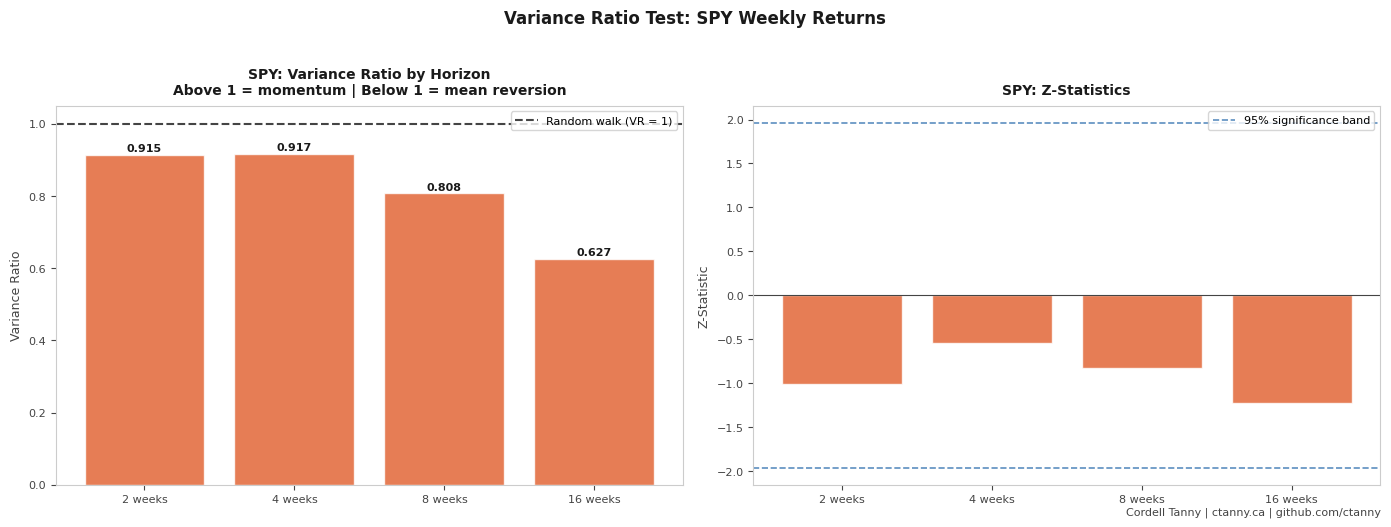

In [ ]:
def plot_vr_results(df_results, ticker, ax_vr, ax_z):
    """
    Plot variance ratios and z-statistics for a single asset.
    """
    horizons = df_results.index.tolist()
    vr_vals  = df_results['VR'].values
    z_vals   = df_results['Z-stat'].values

    colors_vr = ['#2ECC71' if v > 1 else '#E05C2A' for v in vr_vals]
    colors_z  = ['#2ECC71' if z > 0 else '#E05C2A' for z in z_vals]

    ax_vr.bar(horizons, vr_vals, color=colors_vr, alpha=0.8, edgecolor='white')
    ax_vr.axhline(1.0, color='#444444', linewidth=1.5,
                  linestyle='--', label='Random walk (VR = 1)')
    ax_vr.set_title(f'{ticker}: Variance Ratio by Horizon\n'
                    'Above 1 = momentum | Below 1 = mean reversion',
                    fontsize=10, fontweight='bold', color='#1a1a1a', pad=8)
    ax_vr.set_ylabel('Variance Ratio', fontsize=9, color='#444444')
    ax_vr.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
    ax_vr.tick_params(colors='#444444', labelsize=8)
    for sp in ax_vr.spines.values(): sp.set_edgecolor('#cccccc')
    for i, (h, v) in enumerate(zip(horizons, vr_vals)):
        ax_vr.text(i, v + 0.003, f'{v:.3f}', ha='center', va='bottom',
                   fontsize=8, fontweight='bold', color='#1a1a1a')

    ax_z.bar(horizons, z_vals, color=colors_z, alpha=0.8, edgecolor='white')
    ax_z.axhline(1.96,  color='#185FA5', linewidth=1.2,
                 linestyle='--', alpha=0.7, label='95% significance band')
    ax_z.axhline(-1.96, color='#185FA5', linewidth=1.2,
                 linestyle='--', alpha=0.7)
    ax_z.axhline(0, color='#444444', linewidth=0.8)
    ax_z.set_title(f'{ticker}: Z-Statistics',
                   fontsize=10, fontweight='bold', color='#1a1a1a', pad=8)
    ax_z.set_ylabel('Z-Statistic', fontsize=9, color='#444444')
    ax_z.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
    ax_z.tick_params(colors='#444444', labelsize=8)
    for sp in ax_z.spines.values(): sp.set_edgecolor('#cccccc')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
for ax in axes: ax.set_facecolor('white')

plot_vr_results(df_spy, 'SPY', axes[0], axes[1])

plt.suptitle('Variance Ratio Test: SPY Weekly Returns',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.02)
plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('vr_spy_fullsample.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## 4. Interpreting SPY

SPY comes back as a random walk at every horizon tested, and the
result holds up statistically. None of the z-statistics cross the
significance threshold, meaning we cannot distinguish SPY's weekly
return structure from a coin flip at any of the four holding period
horizons.

But look at the direction. All four variance ratios are below 1 and
the gap widens as the horizon extends, from 0.91 at 2 weeks to 0.63
at 16 weeks. The market is not momentum-neutral. It leans toward
mean reversion at the weekly frequency, meaning large weekly moves
in SPY tend to get partially retraced rather than continued. The
signal is not strong enough to reject the random walk statistically,
but the directional lean is consistent and gets more pronounced at
longer horizons.

This is consistent with what we know about broad equity indices.
SPY is one of the most liquid, most efficiently priced instruments
in the world. Hundreds of billions of dollars of capital are
constantly working to eliminate any predictable pattern. The result
here is exactly what market efficiency would predict.

The practical implication is clear. If you are building a
time-series momentum strategy that buys SPY when it has been going
up, this test is telling you there is no statistical foundation for
that approach at weekly to monthly horizons. The market is not
cooperating.

## 5. Full-Sample Test: NVDA

In [ ]:
print("VARIANCE RATIO TEST: NVDA (Weekly Returns)")
print("=" * 60)
df_nvda = run_vr_test(returns['NVDA'], HORIZONS)
print(df_nvda.to_string())

VARIANCE RATIO TEST: NVDA (Weekly Returns)
              VR  Z-stat   p-value Interpretation
Horizon                                          
2 weeks   1.0306  0.6318  0.527541    Random walk
4 weeks   1.0486  0.5530  0.580276    Random walk
8 weeks   1.1003  0.7395  0.459598    Random walk
16 weeks  1.1467  0.7485  0.454183    Random walk


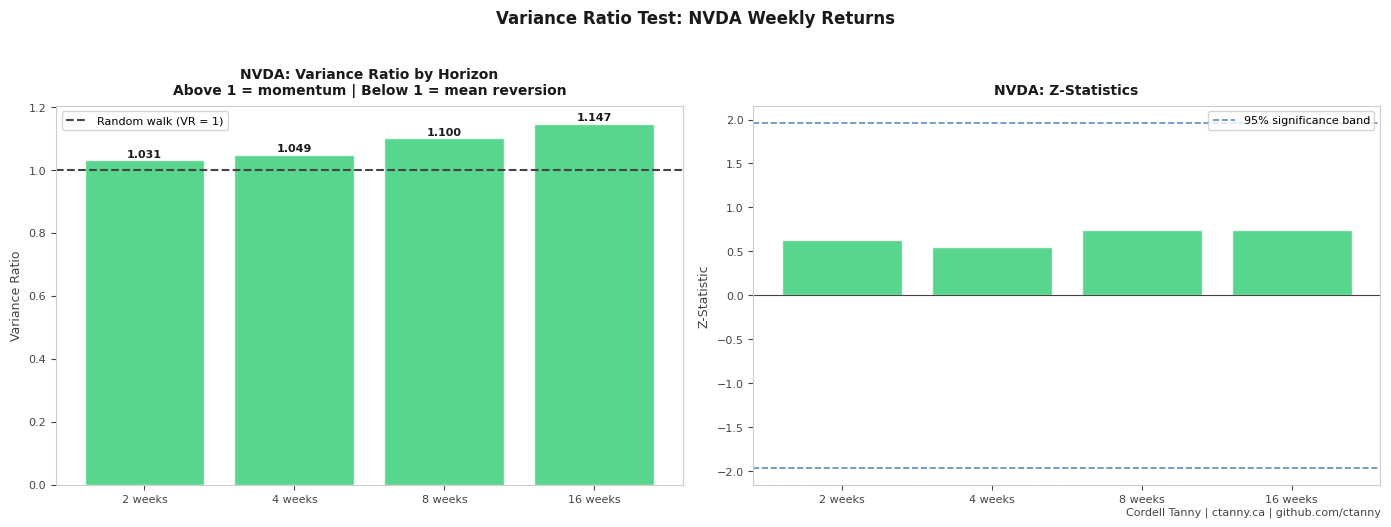

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
for ax in axes: ax.set_facecolor('white')

plot_vr_results(df_nvda, 'NVDA', axes[0], axes[1])

plt.suptitle('Variance Ratio Test: NVDA Weekly Returns',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.02)
plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('vr_nvda_fullsample.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## 6. Interpreting NVDA

NVDA tells a completely different story. All four variance ratios
are above 1, and they increase consistently with horizon from 1.03
at 2 weeks to 1.15 at 16 weeks. The direction is the opposite of
SPY at every single horizon tested.

The z-statistics are positive throughout but do not cross the
significance threshold on their own. Does that mean we should
ignore the result? Not entirely. The consistency of the directional
lean across all four horizons is itself meaningful. A stock that
shows variance ratios above 1 at 2, 4, 8, and 16 weeks is
exhibiting a coherent pattern, not noise. The fact that the signal
strengthens as the horizon extends is exactly what you would expect
from a stock driven by a sustained structural narrative rather than
short-term speculation.

NVDA from 2015 to 2026 was a story stock in the best possible sense.
Gaming, then data centers, then AI. Each narrative wave created
multi-week and multi-month trending behavior as institutional capital
gradually repositioned. That is the kind of environment where
variance ratios above 1 make intuitive sense, and the data confirms
it quantitatively even if the individual horizon results do not clear
the significance bar on their own.

The full-sample result is a yellow flag for caution rather than a
green flag for momentum. It says the historical lean is there. The
rolling test tells you when that lean was actually present and when
it was not.

## 7. Rolling Variance Ratio: SPY

Computing rolling variance ratio for SPY...


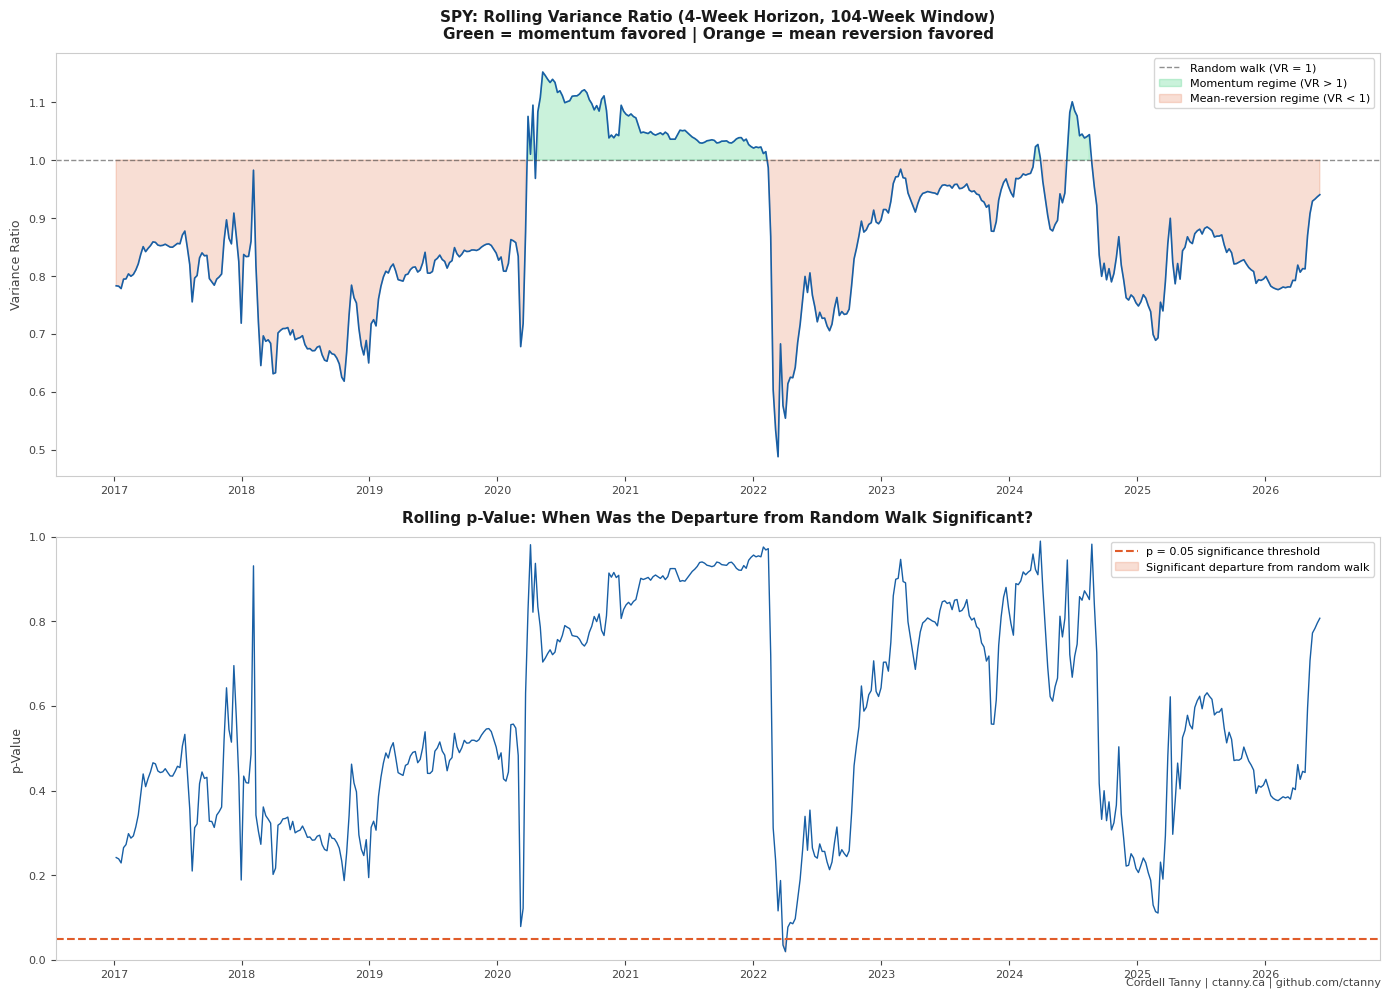

Rolling summary: SPY (4-week horizon, 104-week window)
  VR > 1 (momentum)            : 22.4%
  VR > 1 and significant       : 0.0%
  VR < 1 (mean reversion)      : 77.6%
  VR < 1 and significant       : 0.4%


In [ ]:
def rolling_vr(ret, window, q, alpha=0.05):
    """
    Compute rolling variance ratio using arch library.
    At each step, fit on the trailing window observations only.
    Passes cumulative sum of returns (log price series) to arch.
    """
    r_vals  = ret.values
    r_index = ret.index
    results = []

    for i in range(window, len(r_vals)):
        w          = r_vals[i - window: i]
        log_prices = np.cumsum(w)  # reconstruct log price series
        try:
            vr = VarianceRatio(log_prices, lags=q, robust=True)
            results.append({
                'date'   : r_index[i],
                'vr'     : vr.vr,
                'z_stat' : vr.stat,
                'p_value': vr.pvalue,
            })
        except Exception:
            results.append({
                'date': r_index[i],
                'vr': np.nan, 'z_stat': np.nan, 'p_value': np.nan
            })

    return pd.DataFrame(results).set_index('date').dropna()


def plot_rolling_vr(df_roll, ticker, q, window, alpha=0.05):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.patch.set_facecolor('white')

    axes[0].set_facecolor('white')
    axes[0].plot(df_roll.index, df_roll['vr'],
                 color='#185FA5', linewidth=1.2)
    axes[0].axhline(1.0, color='#444444', linewidth=1.0,
                    linestyle='--', alpha=0.6, label='Random walk (VR = 1)')
    axes[0].fill_between(df_roll.index, df_roll['vr'], 1.0,
                         where=df_roll['vr'] > 1.0,
                         color='#2ECC71', alpha=0.25,
                         label='Momentum regime (VR > 1)')
    axes[0].fill_between(df_roll.index, df_roll['vr'], 1.0,
                         where=df_roll['vr'] < 1.0,
                         color='#E05C2A', alpha=0.2,
                         label='Mean-reversion regime (VR < 1)')
    axes[0].set_title(f'{ticker}: Rolling Variance Ratio '
                      f'({q}-Week Horizon, {window}-Week Window)\n'
                      'Green = momentum favored | Orange = mean reversion favored',
                      fontsize=11, fontweight='bold', color='#1a1a1a', pad=10)
    axes[0].set_ylabel('Variance Ratio', fontsize=9, color='#444444')
    axes[0].legend(fontsize=8, frameon=True,
                   facecolor='white', edgecolor='#cccccc')
    axes[0].tick_params(colors='#444444', labelsize=8)
    for sp in axes[0].spines.values(): sp.set_edgecolor('#cccccc')

    axes[1].set_facecolor('white')
    axes[1].plot(df_roll.index, df_roll['p_value'],
                 color='#185FA5', linewidth=1.0)
    axes[1].axhline(alpha, color='#E05C2A', linewidth=1.5,
                    linestyle='--',
                    label=f'p = {alpha} significance threshold')
    axes[1].fill_between(df_roll.index, df_roll['p_value'], alpha,
                         where=df_roll['p_value'] < alpha,
                         color='#E05C2A', alpha=0.2,
                         label='Significant departure from random walk')
    axes[1].set_title('Rolling p-Value: When Was the Departure from Random Walk Significant?',
                      fontsize=11, fontweight='bold', color='#1a1a1a', pad=10)
    axes[1].set_ylabel('p-Value', fontsize=9, color='#444444')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8, frameon=True,
                   facecolor='white', edgecolor='#cccccc')
    axes[1].tick_params(colors='#444444', labelsize=8)
    for sp in axes[1].spines.values(): sp.set_edgecolor('#cccccc')

    plt.figtext(0.99, 0.01,
                'Cordell Tanny | ctanny.ca | github.com/ctanny',
                ha='right', color='#444444', fontsize=8)
    plt.tight_layout()
    fname = f'vr_rolling_{ticker.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    pct_mom     = (df_roll['vr'] > 1).mean()
    pct_sig_mom = ((df_roll['vr'] > 1) & (df_roll['p_value'] < alpha)).mean()
    pct_mr      = (df_roll['vr'] < 1).mean()
    pct_sig_mr  = ((df_roll['vr'] < 1) & (df_roll['p_value'] < alpha)).mean()

    print(f"Rolling summary: {ticker} ({q}-week horizon, {window}-week window)")
    print(f"  VR > 1 (momentum)            : {pct_mom:.1%}")
    print(f"  VR > 1 and significant       : {pct_sig_mom:.1%}")
    print(f"  VR < 1 (mean reversion)      : {pct_mr:.1%}")
    print(f"  VR < 1 and significant       : {pct_sig_mr:.1%}")


Q_ROLLING = 4  # 4-week horizon
print("Computing rolling variance ratio for SPY...")
df_roll_spy = rolling_vr(returns['SPY'], ROLLING_WINDOW, Q_ROLLING)
plot_rolling_vr(df_roll_spy, 'SPY', Q_ROLLING, ROLLING_WINDOW)


## 8. Interpreting the SPY Rolling Results

The rolling chart for SPY is largely orange, meaning the market
spent most of the past decade in windows where mean reversion
dominated momentum at the 4-week horizon. Only 22.4% of windows
showed a variance ratio above 1, and none of those were
statistically significant.

Two periods stand out. Around 2020 to 2021 the variance ratio
briefly crossed above 1 and the p-value dropped close to the
significance threshold. That was the post-COVID recovery, one of
the strongest and most persistent trending environments in recent
memory. Even then, the momentum signal in SPY was not strong enough
to be statistically reliable.

The second notable period is the sharp drop in March 2022 when the
variance ratio collapsed toward 0.5, the lowest reading in the
entire sample. That coincides with the beginning of the rate shock
and the fastest Federal Reserve tightening cycle in four decades.
The market reversed hard and stayed reversed, producing an
unusually strong mean-reverting signal for an extended period.

The current reading is below 1 and declining, consistent with the
broader pattern of SPY behaving more like a random walk to slightly
mean-reverting series than a momentum asset.

## 9. Rolling Variance Ratio: NVDA

Computing rolling variance ratio for NVDA...


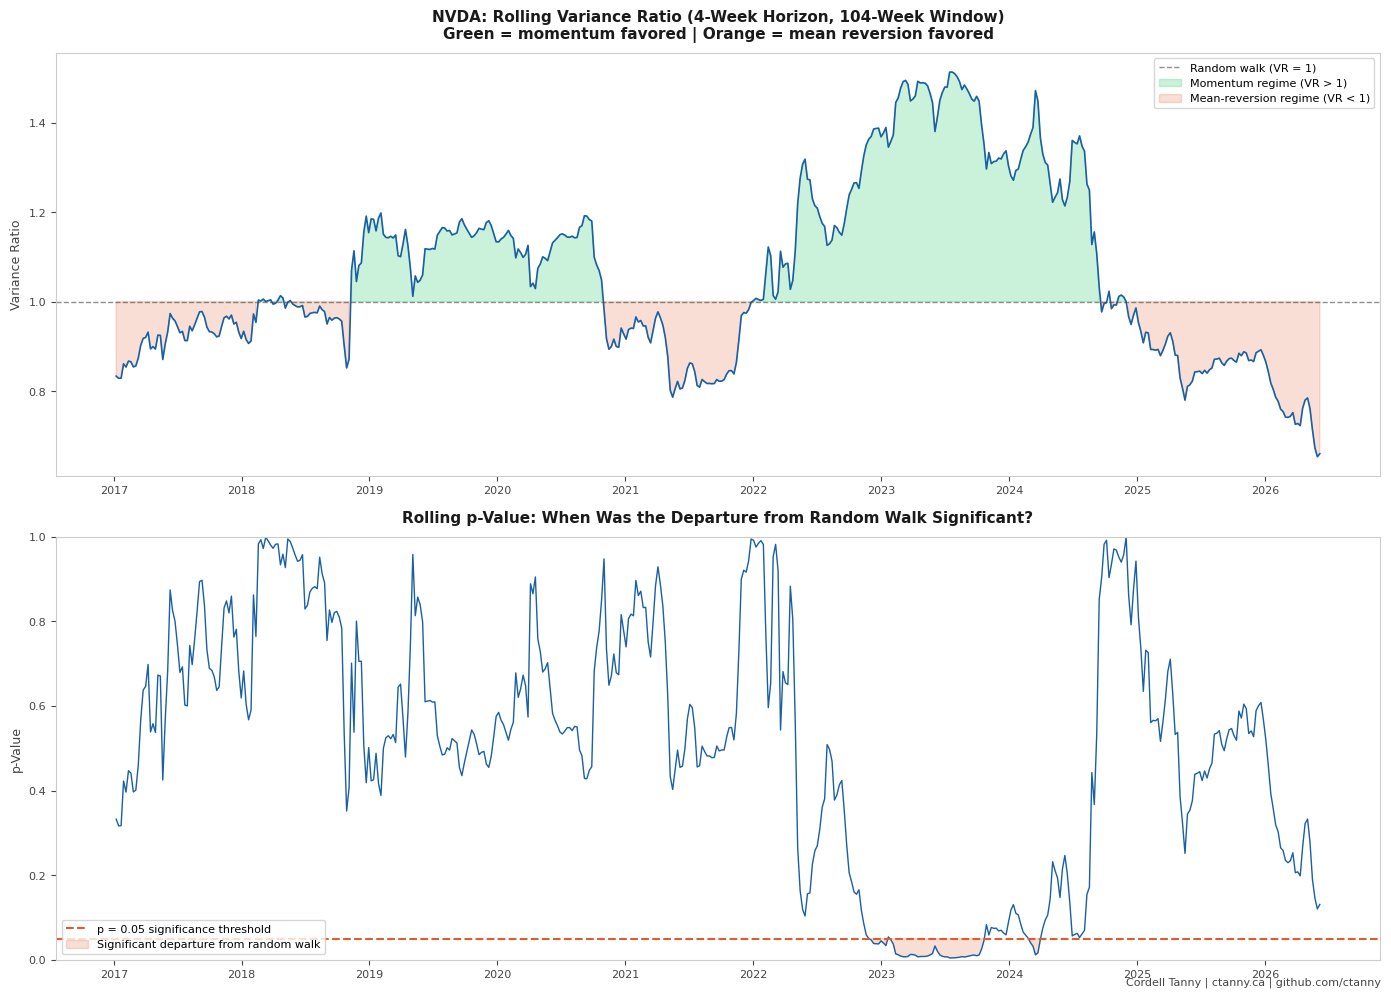

Rolling summary: NVDA (4-week horizon, 104-week window)
  VR > 1 (momentum)            : 52.8%
  VR > 1 and significant       : 10.4%
  VR < 1 (mean reversion)      : 47.2%
  VR < 1 and significant       : 0.0%


In [ ]:
print("Computing rolling variance ratio for NVDA...")
df_roll_nvda = rolling_vr(returns['NVDA'], ROLLING_WINDOW, Q_ROLLING)
plot_rolling_vr(df_roll_nvda, 'NVDA', Q_ROLLING, ROLLING_WINDOW)

## 10. Interpreting the NVDA Rolling Results

This chart is the most interesting output in the notebook. NVDA
spent roughly half its windows above 1 (52.8%), and crucially,
10.4% of all windows produced statistically significant momentum
readings. That is a meaningful and rare finding. For context, SPY
produced zero statistically significant momentum windows across the
same period.

The AI-driven rally from late 2022 through 2024 produced the most
sustained and strongest momentum regime in the sample, with the
rolling variance ratio reaching 1.5 at its peak. This is the
statistical fingerprint of a stock being repriced by a structural
narrative that was large enough and durable enough to produce
genuine multi-week continuation. Every week that NVIDIA reported
another blowout data center revenue quarter, the following weeks
tended to be positive as more capital allocated to the story.

What is happening right now matters. The rolling variance ratio for
NVDA has been falling sharply since late 2024 and is now back below
1. The momentum regime that characterized the AI rally is
deteriorating. This does not mean NVDA will fall. It means the
statistical structure that made buying and holding NVDA for weeks
at a time a high-probability trade is no longer present in the
recent data. The crowded semiconductor trade you are monitoring
has a quantitative signal to accompany the qualitative concern.

## 11. Direct Comparison: SPY vs NVDA

FULL-SAMPLE COMPARISON: SPY vs NVDA
Horizon    | SPY VR   | SPY Z    | SPY Result      | NVDA VR  | NVDA Z   | NVDA Result    
---------------------------------------------------------------------------
2 weeks    |   0.9149 |  -1.0056 | Random walk     |   1.0306 |   0.6318 | Random walk    
4 weeks    |   0.9167 |  -0.5432 | Random walk     |   1.0486 |   0.5530 | Random walk    
8 weeks    |   0.8077 |  -0.8282 | Random walk     |   1.1003 |   0.7395 | Random walk    
16 weeks   |   0.6269 |  -1.2265 | Random walk     |   1.1467 |   0.7485 | Random walk    


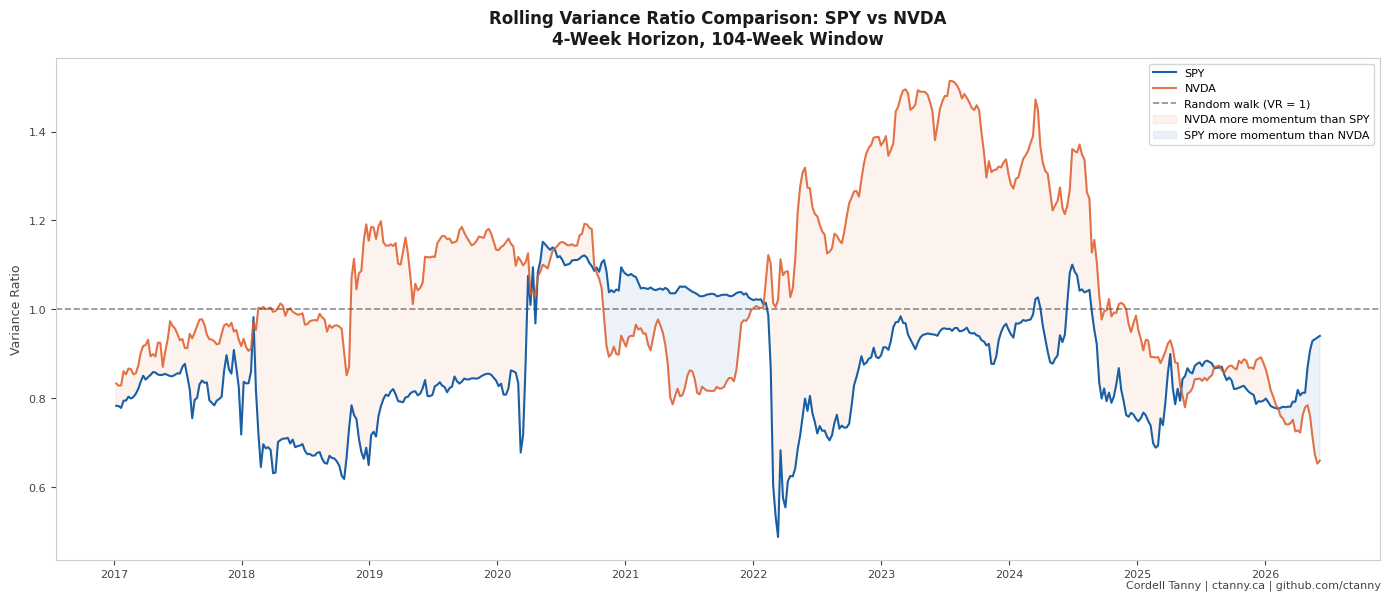

In [ ]:
# Side-by-side full-sample comparison table
print("FULL-SAMPLE COMPARISON: SPY vs NVDA")
print("=" * 75)
print(f"{'Horizon':10s} | {'SPY VR':8s} | {'SPY Z':8s} | {'SPY Result':15s} | "
      f"{'NVDA VR':8s} | {'NVDA Z':8s} | {'NVDA Result':15s}")
print("-" * 75)

for horizon in df_spy.index:
    spy_row  = df_spy.loc[horizon]
    nvda_row = df_nvda.loc[horizon]
    print(f"{horizon:10s} | {spy_row['VR']:8.4f} | {spy_row['Z-stat']:8.4f} | "
          f"{spy_row['Interpretation']:15s} | "
          f"{nvda_row['VR']:8.4f} | {nvda_row['Z-stat']:8.4f} | "
          f"{nvda_row['Interpretation']:15s}")

# Overlay rolling VR comparison chart
# Align on common dates
common = df_roll_spy.index.intersection(df_roll_nvda.index)
spy_common  = df_roll_spy.loc[common, 'vr']
nvda_common = df_roll_nvda.loc[common, 'vr']

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(spy_common.index,  spy_common,  color='#185FA5',
        linewidth=1.5, label='SPY')
ax.plot(nvda_common.index, nvda_common, color='#E05C2A',
        linewidth=1.5, label='NVDA', alpha=0.85)
ax.axhline(1.0, color='#444444', linewidth=1.2,
           linestyle='--', alpha=0.6, label='Random walk (VR = 1)')
ax.fill_between(spy_common.index, spy_common, nvda_common,
                where=nvda_common > spy_common,
                color='#E05C2A', alpha=0.08,
                label='NVDA more momentum than SPY')
ax.fill_between(spy_common.index, spy_common, nvda_common,
                where=spy_common > nvda_common,
                color='#185FA5', alpha=0.08,
                label='SPY more momentum than NVDA')

ax.set_title(f'Rolling Variance Ratio Comparison: SPY vs NVDA\n'
             f'{Q_ROLLING}-Week Horizon, {ROLLING_WINDOW}-Week Window',
             fontsize=12, fontweight='bold', color='#1a1a1a', pad=10)
ax.set_ylabel('Variance Ratio', fontsize=9, color='#444444')
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
ax.tick_params(colors='#444444', labelsize=8)
for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')

plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('vr_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## 12. What the Comparison Tells Us

The overlay chart makes the contrast impossible to miss. For most
of the sample, NVDA's rolling variance ratio sits above SPY's. The
gap is modest from 2017 to 2021, widened dramatically during the
AI rally from 2022 to 2024, and is now converging as NVDA's
momentum structure deteriorates and SPY holds relatively steady.

The full-sample comparison table captures the structural difference
cleanly. SPY leans toward mean reversion at every horizon while NVDA
leans toward momentum at every horizon. The direction is opposite at
all four horizons tested, and the pattern is consistent rather than
noisy. Neither result is statistically significant on its own, but
together they tell a coherent story about the difference between
trading a broad efficient index and trading a high-momentum
individual stock driven by a structural narrative.

The most important takeaway from this comparison is what it implies
for strategy design. A time-series momentum strategy on SPY has no
statistical foundation at the weekly frequency and the historical
data leans against it. The same strategy applied to a stock like
NVDA during the right regime, specifically when the rolling variance
ratio is above 1 and rising, had a genuine statistical edge. The
challenge is identifying that regime in real time before the edge
disappears, which is exactly what the rolling variance ratio is
designed to help you do.

## 13. What This Means for Strategy Design

The variance ratio test is most useful as a pre-flight check before building any directional strategy. Here is how to apply it in practice.

Before building a momentum strategy on any asset, run the test at the holding period horizon you intend to use. If the variance ratio is consistently below 1 at that horizon, you are proposing to build a momentum strategy in an asset that historically mean-reverts at that frequency. No amount of parameter tuning will fix that mismatch.

If the full-sample result is above 1 but not statistically significant, that is a yellow flag. There is a directional lean toward momentum but not enough evidence to build confidence around it. Examine the rolling test to see whether the result is driven by a specific sub-period rather than a consistent structural feature of the asset.

The rolling variance ratio is where the real practical value lives. A strategy running in a window where the rolling VR has dropped below 1 is operating in a mean-reverting environment. Position sizing should reflect that. A falling rolling VR across your trading universe is one of the earliest quantifiable signals that momentum conditions are deteriorating, potentially before the drawdown is visible in returns.

One important caveat: the variance ratio test is backward-looking by construction. A regime that existed in the past may not persist. Use it as evidence, not as certainty.

The most honest use of this test is to rule things out. If the variance ratio test says random walk or mean reversion at your target horizon, that is strong evidence against a momentum strategy on that asset at that frequency. If it says momentum, that is a necessary but not sufficient condition. You still need good execution, realistic transaction costs, and robust out-of-sample testing.

## 14. Key Takeaways

1. Run this test before you build, not after you are disappointed.

The variance ratio test tells you whether momentum has a statistical foundation in your asset at your intended holding period. If the answer is no, you know before writing a single line of backtest code.

2. A variance ratio above 1 means momentum. Below 1 means mean reversion.

The departure from 1 tells you the direction. The z-statistic and p-value tell you whether it is statistically meaningful. Both pieces of information matter. A variance ratio of 1.05 with a p-value of 0.40 is very different from a variance ratio of 1.05 with a p-value of 0.02.

3. Broad indices and individual stocks behave differently.

A broad market index can show mean reversion at the weekly horizon while individual momentum stocks show the opposite. Cross-sectional momentum, which ranks stocks against each other, operates on different dynamics than time-series momentum in a single asset. Testing the index when you are running a stock-selection strategy is testing the wrong thing.

4. Momentum structure changes over time.

The rolling variance ratio is the most practically useful output. It shows you when momentum conditions are favorable and when they are not. A strategy that monitors the rolling VR across its universe is responding to the current environment rather than assuming the past will always hold.

5. The random walk is the null hypothesis.

If you cannot reject it, you have no statistical basis for a momentum strategy. That is not a failure. It is information, and information before building a strategy is worth far more than the same information after a drawdown.

---

What comes next:

A natural extension of this work is to apply the rolling variance ratio across an entire momentum strategy universe, tracking how the aggregate momentum signal quality changes over time. When it deteriorates across the universe, that may be an early warning of a momentum crash before it shows up in returns. I'll leave that to you to test!

---

*Cordell Tanny, CFA, FRM, FDP*  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/quant-finance-snippets](https://github.com/ctanny/quant-finance-snippets)  
*Questions or ideas? Connect on LinkedIn.*

---

*This notebook is for educational and informational purposes only. Nothing contained here constitutes investment advice, a solicitation, or a recommendation to buy or sell any security or financial instrument. The analysis uses historical data to illustrate statistical concepts, not to predict future market behavior. Past performance is not indicative of future results. Readers should consult a qualified financial professional before making any investment decisions.*